In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'tensorflow', 'keras', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'keras': 'keras==3.14.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'tensorflow' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'tensorflow' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'tensorflow.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Language Models

In that section we turned raw text into sequences of tokens.
A *language model* is a probability model over such sequences: given tokens
$x_1, x_2, \ldots, x_T$ drawn from a vocabulary $\mathcal{V}$, it assigns the
whole sequence a joint probability

$$P(x_1, x_2, \ldots, x_T).$$

The chain rule of probability factorizes this joint distribution into a
product of next-token predictions, with no approximation whatsoever:

$$P(x_1, x_2, \ldots, x_T) = \prod_{t=1}^T P(x_t \mid x_1, \ldots, x_{t-1}).$$

For example, the probability of a four-word sequence unrolls as

$$\begin{aligned}&P(\textrm{deep}, \textrm{learning}, \textrm{is}, \textrm{fun}) \\
=&P(\textrm{deep}) P(\textrm{learning}  \mid  \textrm{deep}) P(\textrm{is}  \mid  \textrm{deep}, \textrm{learning}) P(\textrm{fun}  \mid  \textrm{deep}, \textrm{learning}, \textrm{is}).\end{aligned}$$

Modeling language therefore reduces to one deceptively simple subproblem:
estimate $P(x_t \mid x_1, \ldots, x_{t-1})$, the distribution of the next
token given everything that came before. Every language model in this book,
from the count tables below to the largest networks in later chapters, is an
implementation of exactly this conditional.

## What a Language Model Buys You

Why estimate these probabilities? Three capabilities fall out of the
definition, each more consequential than the last.

**Generation.** Because the equation writes the joint as a
chain of conditionals, we can *sample* text one token at a time: draw
$x_t \sim P(x_t \mid x_{t-1}, \ldots, x_1)$, append it to the context, and
repeat. Any model of next-token probabilities is automatically a text
generator, and the fidelity of what it writes is a direct readout of the
quality of its conditionals, a readout we will use throughout the chapter.

**Scoring.** A language model can rank competing hypotheses by how plausible
they are as language. The phrases "to recognize speech" and "to wreck a nice
beach" sound nearly identical, so an acoustic model alone cannot tell them
apart; a language model settles the matter immediately, since the second
phrase is vastly less probable as English. Speech recognizers, translation
systems, and spelling correctors have all been built this way: one model
proposes candidates, a language model scores them.

**Everything expressible as a continuation.** The modern realization is that
almost any task can be *phrased* as next-token prediction. Continue "The
novella The Time Machine was written by" and you answer a factual question;
continue "'Where is the library?' translates into French as" and you
translate. A single sufficiently good model of $P(x_t \mid x_{<t})$, trained
on enough text, becomes a universal interface to every task whose input and
output can be spelled out as tokens. Large language models, to which we
return in that section, are this observation
pushed to scale, and they are built from exactly the machinery this chapter
develops.

This section builds language models the simplest way imaginable, by counting
(that section); examines the statistics of
language that doom counting (that section); develops
the metrics by which language models are judged
(that section); and prepares the training data pipeline for
the neural language models of the coming sections
(that section).

In [1]:
import collections
import math
import random
import re
from d2l import tensorflow as d2l
import tensorflow as tf

## $n$-gram Language Models

### Markov Models and Counting

The conditional in the equation looks innocent but hides a
problem: its context $x_1, \ldots, x_{t-1}$ grows with $t$, so the number of
distinct contexts we would have to model is unbounded. The classical way out
is the Markov assumption from that section: pretend that
only the most recent $n-1$ tokens matter,

$$P(x_t \mid x_1, \ldots, x_{t-1}) \approx P(x_t \mid x_{t-n+1}, \ldots, x_{t-1}).$$

A model using no context at all ($n=1$) is called a *unigram* model, one
conditioning on a single previous token ($n=2$) a *bigram* model, on two
previous tokens ($n=3$) a *trigram* model, and so on. These conditional
probabilities are the language model's parameters, and estimating them could
not appear easier: by maximum likelihood, the estimate of a conditional
probability is just a ratio of counts. Writing $N(\cdot)$ for the number of
occurrences of an $n$-gram in the training corpus,

$$\hat{P}(x_t \mid x_{t-n+1}, \ldots, x_{t-1}) = \frac{N(x_{t-n+1}, \ldots, x_{t})}{N(x_{t-n+1}, \ldots, x_{t-1})}.$$

An $n$-gram language model is nothing more than a big table of these ratios.

Let's build such tables on *The Time Machine*. Our neural language models
will consume the BPE tokens of that section; here we
tokenize into *words* instead, purely because the point of this exercise is
to read the model's output, and words are easier to read than subword
fragments. We reuse the normalization of that section (strip
punctuation, lowercase), split on whitespace, and hold out the final 10% of
the text to later judge the models on text they did not see.

In [2]:
fname = d2l.download(d2l.DATA_URL + 'timemachine.txt',
                     sha1_hash='090b5e7e70c295757f55df93cb0a180b9691891a')
raw_text = open(fname).read()
text = re.sub('[^A-Za-z]+', ' ', raw_text).lower()
split = text.rindex(' ', 0, int(0.9 * len(text)))
words_train, words_val = text[:split].split(), text[split:].split()
len(words_train), len(words_val)

(29402, 3373)

The model class below holds, for every context of $n-1$ tokens, a counter
of the tokens that followed it in training; that is all
the equation needs. The `prob` method returns a smoothed
conditional probability (the constant `alpha` is explained shortly), while
`sample` extends a prefix by drawing each next token in proportion to the
raw counts, exactly the generation recipe of the equation.
Both look only at the most recent $n-1$ tokens of the context they are
handed.

In [3]:
class NGramLM:
    """An n-gram language model estimated from counts."""
    def __init__(self, tokens, n, vocab_size, alpha=0.01):
        self.n, self.vocab_size, self.alpha = n, vocab_size, alpha
        cont = collections.defaultdict(collections.Counter)
        for gram in zip(*(tokens[i:] for i in range(n))):
            cont[gram[:-1]][gram[-1]] += 1
        self.cont = dict(cont)
        self.total = {ctx: sum(c.values()) for ctx, c in self.cont.items()}

    def prob(self, context, token):
        """Laplace-smoothed P(token | last n-1 tokens of context)."""
        ctx = tuple(context[len(context) - self.n + 1:])
        num = self.cont.get(ctx, {}).get(token, 0) + self.alpha
        return num / (self.total.get(ctx, 0) + self.alpha * self.vocab_size)

    def sample(self, prefix, num_tokens, rng):
        """Extend prefix by sampling from the unsmoothed count model."""
        out = list(prefix)
        for _ in range(num_tokens):
            ctx = tuple(out[len(out) - self.n + 1:])
            counts = self.cont[ctx]
            out.append(rng.choices(list(counts), counts.values())[0])
        return out

vocab_size = len(set(words_train + words_val))
models = {n: NGramLM(words_train, n, vocab_size) for n in (1, 2, 3)}

### Sampling from $n$-gram Models

Now the readout. We hand each model the same two-word prefix and let it
generate 25 tokens.

In [4]:
rng = random.Random(0)
for n, model in models.items():
    print(f'{n}-gram:', ' '.join(model.sample(['the', 'time'], 25, rng)))

1-gram: the time import meat on and looking they immediately in any up examination some and grew s his narrow fortunate risk matches in their cold good but
2-gram: the time machine and holding one indeed no refuge there came one direction i saw for which i ve told blank the soil smelt sweet and blackening
3-gram: the time traveller then when we were i put out my hand i had expected happened the bronze doors as yet i had hitherto seen it was


The progression is unmistakable. The unigram model emits words with the
right marginal frequencies but no relationship to one another: word salad.
The bigram model produces locally plausible pairs that drift without
direction, since each word remembers only its immediate predecessor. The
trigram output suddenly reads like Wells. Two tokens of context are enough
to capture much of the local syntax of English, and this is precisely why
$n$-gram models powered practical speech recognition and translation systems
for decades.

Before celebrating, look closer at the trigram text: whole clauses are
lifted verbatim from the novella. With two words of context on a small
corpus, most contexts have been seen only once, so the "model" often has a
single continuation available and simply replays its training data. It has
memorized rather than generalized. Rerun the cell with other seeds and you
will find entire sentences of Wells reproduced wholesale.

### The Sparsity Wall

Memorization is a symptom of a deeper quantitative problem. The number of
*possible* $n$-grams is $|\mathcal{V}|^n$, exploding exponentially in $n$,
while the number of $n$-grams a corpus can exhibit grows only linearly with
its length. We can measure the resulting sparsity directly: for each order,
what fraction of held-out $n$-grams has a training count of zero?

In [5]:
for n in (1, 2, 3):
    seen = set(zip(*(words_train[i:] for i in range(n))))
    grams = list(zip(*(words_val[i:] for i in range(n))))
    rate = sum(gram not in seen for gram in grams) / len(grams)
    print(f'unseen held-out {n}-grams: {rate:.1%} '
          f'({len(seen)} distinct in training)')

unseen held-out 1-grams: 8.4% (4315 distinct in training)
unseen held-out 2-grams: 51.5% (18535 distinct in training)
unseen held-out 3-grams: 87.0% (26982 distinct in training)


The wall is steep: roughly one word in twelve is new, but half of all word
*pairs* and nearly nine out of ten word *triples* in the held-out text never
occurred in training. Under the maximum likelihood estimate
the equation every one of them gets probability zero, and a single
zero multiplies through the equation to declare the entire
held-out text impossible.

The classical remedy is *Laplace smoothing*: pretend every count is a little
larger than observed, adding a constant $\alpha > 0$ to the numerator and
compensating in the denominator so the probabilities still sum to one,

$$\hat{P}(x_t \mid x_{t-n+1}, \ldots, x_{t-1}) = \frac{N(x_{t-n+1}, \ldots, x_{t}) + \alpha}{N(x_{t-n+1}, \ldots, x_{t-1}) + \alpha |\mathcal{V}|}.$$

The idea predates language modeling by two centuries: Laplace introduced it
(with $\alpha = 1$) to argue about the probability that the sun will rise
tomorrow given that it has risen every day so far. Decades of research
refined the equation into far cleverer schemes that
interpolate across orders and discount frequent events, of which Kneser--Ney
smoothing became the standard and Bayesian nonparametrics the most elegant
expression [@Wood.Gasthaus.Archambeau.ea.2011]. But no smoothing scheme
escapes the underlying predicament: it can only redistribute probability
mass, not *know* anything about unseen events. That "cat" and "feline"
should behave alike, that "I want to eat, grandma" is benign while "I want
to eat grandma" is not, is invisible to a count table, which treats every
token as an unrelated symbol. Sharing statistical strength across related
words and contexts requires learned representations, and that is where
neural networks enter in that section.

## Word Frequency and Zipf's Law

How quickly does the sparsity wall rise? The answer lies in the frequency
statistics of natural language, which hold for essentially every corpus in
every language. We use the `Vocab` class of that section,
which orders tokens by frequency, and inspect the most common words of *The
Time Machine*.

In [6]:
words = text.split()
vocab = d2l.Vocab(words)
vocab.token_freqs[:10]

[('the', 2261),
 ('i', 1267),
 ('and', 1245),
 ('of', 1155),
 ('a', 816),
 ('to', 695),
 ('was', 552),
 ('in', 541),
 ('that', 443),
 ('my', 440)]

The ten most frequent words are not descriptive of time travel at all. They
are articles, pronouns, and prepositions, so-called *stop words*, and a
random Victorian novel would yield much the same list. More interesting is
how fast the frequencies decay: the tenth most common word is already less
than a fifth as frequent as the most common one. Plotting frequency against
rank on log-log axes reveals the pattern.

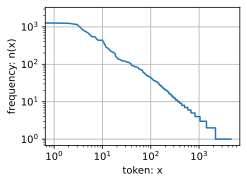

In [7]:
freqs = [freq for token, freq in vocab.token_freqs]
d2l.plot(freqs, xlabel='token: x', ylabel='frequency: n(x)',
         xscale='log', yscale='log')

Past the first few words, the curve is close to a straight line on log-log
axes. This is *Zipf's law*: the frequency $n_i$ of the $i$-th most frequent
word obeys

$$n_i \propto \frac{1}{i^\alpha},$$

equivalently $\log n_i = -\alpha \log i + c$ for an exponent $\alpha$ and
constant $c$. A power law has a heavy tail: a large fraction of all
occurrences belongs to words that are individually rare. Does the same hold
for word pairs and triples? We can lay all three curves on common axes.

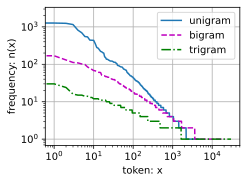

In [8]:
bigrams = ['--'.join(pair) for pair in zip(words[:-1], words[1:])]
trigrams = ['--'.join(tri) for tri in zip(
    words[:-2], words[1:-1], words[2:])]
bigram_freqs = [freq for token, freq in d2l.Vocab(bigrams).token_freqs]
trigram_freqs = [freq for token, freq in d2l.Vocab(trigrams).token_freqs]
d2l.plot([freqs, bigram_freqs, trigram_freqs], xlabel='token: x',
         ylabel='frequency: n(x)', xscale='log', yscale='log',
         legend=['unigram', 'bigram', 'trigram'])

Three observations. First, bigrams and trigrams follow Zipf's law too, with
smaller exponents, so language is power-law distributed at every order of
context. Second, the total number of distinct $n$-grams is far smaller than
$|\mathcal{V}|^n$: there is a great deal of structure in language, which is
why modeling it is possible at all. Third, and decisive for $n$-gram models:
the curves shift toward count one as $n$ grows. Most distinct trigrams occur
exactly once, so their conditional probability estimates rest on a single
observation, and the trigrams of unseen text mostly fall off the table
entirely, as we measured above. The tail is where count-based models die.
Any approach that estimates each sequence's probability separately needs
exponentially more data as the context grows; models that *generalize*
across related contexts are the way forward.

## Perplexity and Bits per Byte

### Perplexity

Sampling gave us a qualitative readout of model quality; now we need a
number. How to obtain one is less obvious than it seems. One way to think
about it is to check how surprising the text is to the model. A good
language model predicts, with high accuracy, the tokens that come next.
Consider the following continuations of the phrase "It is raining", as
proposed by three different language models:

1. "It is raining outside"
1. "It is raining banana tree"
1. "It is raining piouw;kcj pwepoiut"

Example 1 is clearly the best. The words are sensible and logically
coherent. While it might not quite accurately reflect which word follows
semantically ("in San Francisco" and "in winter" would have been perfectly
reasonable extensions), the model captures which kind of word follows.
Example 2 is considerably worse, producing a nonsensical extension.
Nonetheless, at least the model has learned how to spell words and some
degree of correlation between them. Finally, example 3 indicates a poorly
trained model that does not fit the data properly.

We might measure the quality of the model by computing the likelihood of a
sequence. Unfortunately this is a number that is hard to understand and
difficult to compare: shorter sequences are much more likely than longer
ones, so evaluating the model on Tolstoy's magnum opus *War and Peace* will
inevitably produce a much smaller likelihood than on Saint-Exupery's
novella *The Little Prince*. What is missing is the equivalent of an
average.

Information theory supplies it. We defined entropy, surprisal, and
cross-entropy when we introduced softmax regression
(that section). If we want to compress text, we can
ask about predicting the next token given the current set of tokens: a
better language model lets us spend fewer bits per token. So we measure a
model by the cross-entropy loss averaged over all $T$ tokens of a sequence,

$$\frac{1}{T} \sum_{t=1}^T -\log P(x_t \mid x_{t-1}, \ldots, x_1),$$

where $P$ is given by the language model and $x_t$ is the actual token
observed at time step $t$. This makes performance on documents of different
lengths comparable. For historical reasons, natural language processing
prefers the exponential of the equation, called *perplexity*
[@Jelinek.Mercer.Bahl.ea.1977]:

$$\exp\left(-\frac{1}{T} \sum_{t=1}^T \log P(x_t \mid x_{t-1}, \ldots, x_1)\right).$$

Perplexity is best understood as the geometric mean of the number of real
choices the model faces when deciding which token comes next, its
*effective branching factor*. Three reference points make the scale
concrete:

* In the best case, the model always assigns the target token probability 1,
  and the perplexity is 1.
* In the worst case, the model assigns some target token probability 0, and
  the perplexity is infinite.
* At the baseline, the model predicts a uniform distribution over the
  vocabulary, and the perplexity equals $|\mathcal{V}|$, the number of
  distinct tokens. Storing the sequence without any compression costs
  exactly this many choices per token, so this is an upper bound that any
  useful model must beat.

The worst case is not hypothetical: it is what an unsmoothed $n$-gram model
does on every unseen $n$-gram, of which the held-out text is full. Smoothing
the equation exists precisely so that perplexity stays
finite. Let's evaluate our three word-level models on the held-out split.

In [9]:
def eval_nll(model, tokens):
    """Total negative log-likelihood of tokens, in nats."""
    return -sum(math.log(model.prob(tokens[:t], tokens[t]))
                for t in range(len(tokens)))

for n, model in models.items():
    ppl = math.exp(eval_nll(model, words_val) / len(words_val))
    print(f'{n}-gram held-out perplexity: {ppl:8.1f}')

1-gram held-out perplexity:    840.7
2-gram held-out perplexity:    775.1
3-gram held-out perplexity:   2618.1


The result should give you pause: the trigram model, which wrote by far the
most convincing text, has by far the *worst* held-out perplexity, and even
the bigram barely improves on the unigram. Both facts are the sparsity wall
in disguise. When 87% of held-out trigrams are unseen, the trigram model
spends most of its time on smoothed near-uniform guesses, and no choice of
$\alpha$ rescues it (the exercises ask you to try). Good-looking samples and
good generalization are different things, and the gap between them is
memorization. Closing that gap, achieving low perplexity on *unseen* text,
is the actual job of a language model, and perplexity will be our chief
metric for the neural models of the coming sections.

### Bits per Byte

One subtlety hides in "per token": perplexity depends on what a token *is*.
A character model chooses among 27 symbols per step while our word model
chooses among thousands, so their perplexities are not remotely comparable.
Since that section taught us that tokenization itself is a
design choice, a fair metric must not depend on it. The fix is to change
the denominator: divide the total surprisal not by the number of tokens, a
tokenizer-dependent quantity, but by the number of *bytes* of text, a
property of the data alone. Measuring surprisal in bits (base-2 logarithms)
gives *bits per byte*,

$$\textrm{bpb} = \frac{1}{B} \sum_{t=1}^T -\log_2 P(x_t \mid x_{t-1}, \ldots, x_1),$$

where $B$ is the length of the evaluated text in UTF-8 bytes. This is a
compression rate: a model with bits per byte $b$ can, paired with an
arithmetic coder, compress the text to a fraction $b/8$ of its raw size.
One experiment makes the contrast between the two metrics visible: the same
model class (a trigram with the same smoothing) estimated on the same
training text under three tokenizations, characters, our vocabulary-1,024
BPE from that section, and words.

In [10]:
bpe = d2l.BPETokenizer(vocab_size=1024, pattern=d2l.BPETokenizer.GPT2_PATTERN)
bpe.train(text[:split])
streams = {'character': (list(text[:split]), list(text[split:]),
                         len(set(text))),
           'BPE (1,024)': (bpe.encode(text[:split]), bpe.encode(text[split:]),
                           bpe.vocab_size),
           'word': (words_train, words_val, vocab_size)}
n_bytes = len(text[split:].encode('utf-8'))
print(f'{"tokenization":>12} {"|V|":>5} {"tokens":>7} {"ppl":>8} {"bpb":>5}')
for name, (train, val, m) in streams.items():
    nll = eval_nll(NGramLM(train, 3, m), val)
    print(f'{name:>12} {m:>5} {len(val):>7} '
          f'{math.exp(nll / len(val)):>8.1f} {nll / math.log(2) / n_bytes:>5.2f}')

tokenization   |V|  tokens      ppl   bpb


   character    27   17345      6.4  2.68
 BPE (1,024)  1024    5509    281.6  2.58
        word  4579    3373   2618.1  2.21


Judged by perplexity the three models look incomparably different, spanning
more than two orders of magnitude; judged by bits per byte they are nearly
tied, and the ordering even reverses: the character model has the lowest
perplexity yet compresses *worst*, because at a fixed order $n$ coarser
tokens condition on more actual text. Two words of context reach some
fifteen characters back, two characters of context barely finish a syllable.
The word model "wins" here only because we quietly told it the held-out
vocabulary in advance; the byte-level BPE model needs no such favor, which
is one more reason modern models use subword tokenization.

Because bits per byte is tokenizer-independent, it is how modern language
modeling runs are compared: a training run with a 50,000-token vocabulary
and one with a 200,000-token vocabulary cannot be compared by perplexity at
all, but their bits per byte are directly commensurable. The magnitudes are
worth remembering. Shannon estimated, using human predictions, that printed
English carries around one bit per character [@Shannon.1951]; strong
neural language models now compress diverse web text below one bit per byte,
while our best count-based model sits above two. The distance between those
numbers is the distance this part of the book travels.

## Partitioning Sequences

We close by preparing the data pipeline for the neural language models of
the coming sections: they will be trained on the BPE token ids of
that section, consumed as minibatches of fixed-length
subsequences.

Suppose the corpus is a stream of $T$ token ids. We form *all* overlapping
subsequences of length $n$ (here $n$ plays the role of a sequence length,
`num_steps`, not an $n$-gram order): denote by
$\mathbf x_t = [x_t, \ldots, x_{t+n-1}]$ the subsequence starting at
position $t$, giving candidates $\mathbf x_0, \mathbf x_1, \ldots,
\mathbf x_{T-n-1}$. Since a language model predicts the next token from the
tokens so far, the target for input $\mathbf x_t$ is the same window shifted
forward by one position, $\mathbf x_{t+1}$: while the model reads $x_t,
\ldots, x_{t+n-1}$ it is trained to emit $x_{t+1}, \ldots, x_{t+n}$, token
by token. the figure shows two such (input, target) pairs
over the actual opening tokens of our corpus. At training time we draw
minibatches of pairs at random from the full overlapping collection, which
provides the stochasticity that stochastic gradient descent expects without
discarding any position in the corpus.

![Partitioning a stream of BPE token ids into overlapping length-5 input subsequences. The target of each input window is the same window shifted forward by one token; a minibatch gathers windows drawn at random.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-rnn-partitioning.svg)

The constructor below assembles the full pipeline: download the corpus,
train the tokenizer of that section on it (byte-level BPE
with the GPT-2 pre-tokenization pattern), encode the corpus into token ids,
and lay out all overlapping input and target windows as rows of two aligned
arrays. The trained tokenizer remains available as `data.tokenizer`, so ids
can be decoded back into text; `data.vocab` refers to it as well, so
`len(data.vocab)` gives the vocabulary size in either mode. Passing
`tokenization='char'` selects the character-level pipeline of
that section instead, which several exercises use to compare
tokenizations end to end.

In [11]:
@d2l.add_to_class(d2l.TimeMachine)
def __init__(self, batch_size, num_steps, num_train=10000, num_val=5000,
             tokenization='bpe', vocab_size=1024):
    super(d2l.TimeMachine, self).__init__()
    self.save_hyperparameters()
    raw_text = self._download()
    if tokenization == 'bpe':
        self.tokenizer = d2l.BPETokenizer(
            vocab_size, pattern=d2l.BPETokenizer.GPT2_PATTERN)
        self.tokenizer.train(raw_text)
        corpus, self.vocab = self.tokenizer.encode(raw_text), self.tokenizer
    else:  # 'char': the character-level pipeline
        corpus, self.vocab = self.build(raw_text)
    array = d2l.tensor([corpus[i:i+num_steps+1]
                        for i in range(len(corpus)-num_steps)])
    self.X, self.Y = array[:,:-1], array[:,1:]

Training and validation use disjoint ranges of window positions. The data
loader samples minibatches of (input, target) rows at random for training
and sequentially for validation.

In [12]:
@d2l.add_to_class(d2l.TimeMachine)
def get_dataloader(self, train):
    idx = slice(0, self.num_train) if train else slice(
        self.num_train, self.num_train + self.num_val)
    return self.get_tensorloader([self.X, self.Y], train, idx)

Each minibatch is a pair of integer arrays of shape (`batch_size`,
`num_steps`), and the target array is the input array shifted by one token.
Decoding a row confirms that the ids really are Wells' prose, and that
input and target are the same text one token apart.

In [13]:
data = d2l.TimeMachine(batch_size=2, num_steps=10)
for X, Y in data.train_dataloader():
    print('X:', X, '\nY:', Y)
    break
print('X[0]:', repr(data.tokenizer.decode([int(i) for i in X[0]])))
print('Y[0]:', repr(data.tokenizer.decode([int(i) for i in Y[0]])))

X: tf.Tensor(
[[293 333 502 102 259 919 453 260  10  98]
 [524  45 267 264 571 601 480 649 545 491]], shape=(2, 10), dtype=int32) 
Y: tf.Tensor(
[[333 502 102 259 919 453 260  10  98 274]
 [ 45 267 264 571 601 480 649 545 491 260]], shape=(2, 10), dtype=int32)
X[0]: ' lay unfinished upon the\nb'
Y[0]: 'ay unfinished upon the\nben'


## Summary and Discussion

Language models assign probabilities to token sequences, and the chain rule
reduces them to next-token prediction, which makes one model a generator, a
scorer of hypotheses, and, at scale, an interface to any task expressible as
a continuation. $n$-gram models implement the conditional with counts under
a Markov assumption; they are trivial to estimate and already write locally
convincing text, but Zipf's law guarantees that the count tables go sparse
exponentially fast in $n$, so they memorize rather than generalize, and
smoothing can only paper over the zeros. Perplexity, the exponentiated
average cross-entropy, is the standard quality metric, interpretable as an
effective branching factor; because it is defined per token it cannot
compare models with different tokenizers, for which bits per byte is the
tokenizer-independent standard. Finally, we prepared the training pipeline
used in the rest of this chapter: the corpus becomes one stream of BPE token
ids, cut into all overlapping fixed-length windows, with targets shifted by
one token and minibatches drawn at random.

Language models scale with data, model size, and compute. Trained on
internet-scale corpora, the same next-token objective yields systems that
perform tasks from translation to coding when prompted with an appropriate
context. We will return to what emerges from that scaling in
that section; the next sections build the
first neural architectures of that lineage.

## Exercises

1. In `NGramLM.sample` we drew each next token in proportion to its raw
   count $N$. Add a *temperature* $\tau > 0$ by sampling in proportion to
   $N^{1/\tau}$, and generate trigram text at $\tau \in \{0.3, 1, 3\}$.
   Describe what changes. What distribution do you recover as
   $\tau \to 0$, and as $\tau \to \infty$? Temperature is the first dial of
   the decoding toolkit we develop later in this chapter.
1. Consider a 5-gram model over a realistic vocabulary of
   $|\mathcal{V}| = 50{,}000$ word tokens. How many entries would a dense
   table of conditional probabilities contain? If you instead store only
   the 5-grams observed in a trillion-token corpus, at 16 bytes per entry,
   how much memory do you need at most, and what fraction of all possible
   5-grams have you covered? What does this imply about querying the table
   on new text?
1. Show that a model achieving per-token perplexity $p$ on a text that its
   tokenizer splits into $T$ tokens and whose size is $B$ UTF-8 bytes
   attains $\textrm{bpb} = (T/B) \log_2 p$. Verify the formula on the rows
   of the table in that section. What held-out perplexity
   would the BPE-level trigram need in order to reach one bit per byte?
1. Sweep the smoothing constant $\alpha$ over
   $\{1, 0.1, 0.01, 0.001, 0.0001\}$ for the unigram, bigram, and trigram
   word models and plot held-out perplexity against $\alpha$ on a log
   axis. Why does the best $\alpha$ shrink as $n$ grows? Is there any
   $\alpha$ for which the trigram beats the bigram? Explain your finding
   using the unseen-$n$-gram rates measured in
   that section.

[Discussions](https://d2l.discourse.group/t/1049)